## Diabetes Readmission Prediction

#### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.model_selection import RepeatedStratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline

#### Load Dataset

In [ ]:
# Read the dataset
US_diab_readmission = pd.read_csv("../Diabetes Dataset/diabetic_data.csv")

In [3]:
# Load the first 5 rows of the dataset
US_diab_readmission.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Load the last 5 rows of the dataset
US_diab_readmission.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


#### Analysing the Dataset

In [5]:
US_diab_readmission.columns.to_list()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [6]:
# Observe the datasets size
US_diab_readmission.shape

(101766, 50)

In [7]:
US_diab_readmission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
# Understanding the datasets statistics
US_diab_readmission.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


#### Data Cleaning

In [ ]:
# Calculating missing values by features
total_missing_val = (US_diab_readmission.isnull().sum()/len(US_diab_readmission)*100)
top_missing_val = total_missing_val[total_missing_val > 0].sort_values(ascending=False)
print(top_missing_val)

max_glu_serum    94.746772
A1Cresult        83.277322
dtype: float64


C:\Users\Johnson\AppData\Local\Temp\ipykernel_7144\2621688641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_missing_val.index, y=top_missing_val, palette="Set2")


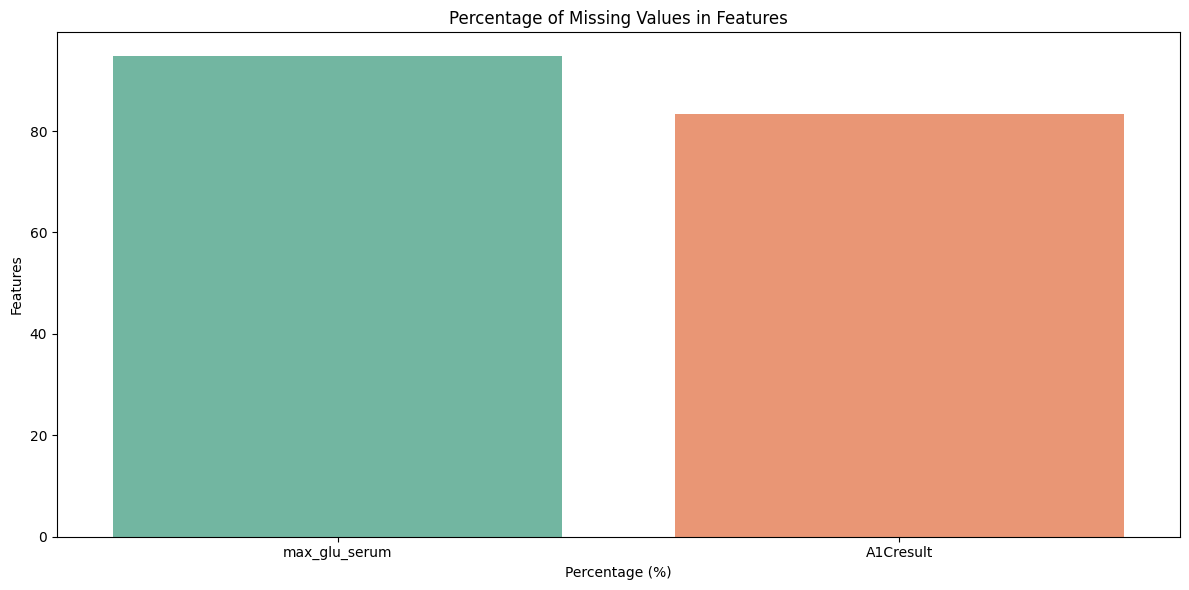

In [35]:
# Visualising missing values by features
plt.figure(figsize=(12,6))
sns.barplot(x=top_missing_val.index, y=top_missing_val, palette="Set2")
plt.xlabel("Percentage (%)")
plt.ylabel("Features")
plt.title("Percentage of Missing Values in Features")
plt.tight_layout()
plt.show()

In [ ]:
# Features: "max_glu_serum" and "A1Cresult" hold high null values
# Therefore, they will be dropped
US_diab_readmission = US_diab_readmission.drop(columns=["max_glu_serum", "A1Cresult"])

In [38]:
# The dataset presents NAN values as "?" character
# Calculating the percentage of "?" characters by features
Character_val = ((US_diab_readmission == "?").sum()/len(US_diab_readmission)*100)
top_character_val = Character_val[Character_val > 0].sort_values(ascending=False)
print(top_character_val)

weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


C:\Users\Johnson\AppData\Local\Temp\ipykernel_7144\2809441396.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_character_val.index, y=top_character_val, palette="Set2")


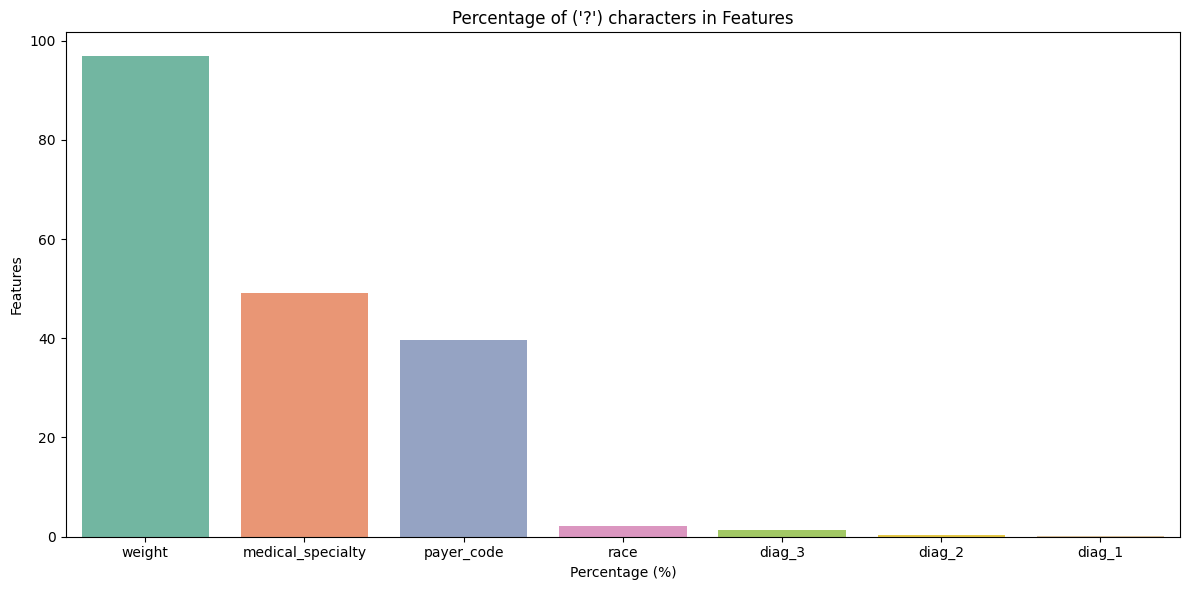

In [39]:
# Visualising the percentage of "?" characters by features
plt.figure(figsize=(12,6))
sns.barplot(x=top_character_val.index, y=top_character_val, palette="Set2")
plt.xlabel("Percentage (%)")
plt.ylabel("Features")
plt.title("Percentage of ('?') characters in Features")
plt.tight_layout()
plt.show()

In [ ]:
# The top 3 features has the highest null values, imputing them in will hold no value
# Therefore, they will be dropped
US_diab_readmission = US_diab_readmission.drop(columns=["weight", "medical_specialty", "payer_code"])

In [41]:
#To process the remaining features with null values
#The "?" value needs to be replaced with np.nan
US_diab_readmission = US_diab_readmission.replace("?", np.nan)

In [ ]:
# Imputing the remaining columns using Mode.
impute_remaining_col = ["diag_3", "diag_2", "diag_1", "race"]
US_diab_readmission[impute_remaining_col] = US_diab_readmission[impute_remaining_col].fillna(US_diab_readmission[impute_remaining_col].mode().iloc[0])

In [ ]:
# Final null value check
US_diab_readmission.isna().sum().sort_values(ascending=False)

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide

In [44]:
# # Final duplicate value check
US_diab_readmission.duplicated().sum()

np.int64(0)

#### Data Preprocessing

#### Exploratory Data Analysis

In [ ]:
US_diab_readmission.head()

In [ ]:
#Features: "encounter_id" and "patient_nbr" are unique indentifiers that holds no meaningful values

US_diab_readmission = US_diab_readmission.drop(columns=["encounter_id", "patient_nbr"])
US_diab_readmission.shape

In [ ]:
US_diab_readmission.head()

In [ ]:
#Data visualisation for feature: race

feat_race = US_diab_readmission["race"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_race.index, feat_race.values)
plt.xlabel("Race")
plt.ylabel("Index")
plt.title("Race - Value Distribution")
plt.show()

#Caucasian value count is the highest
#The plot suggests that there is data imbalance

In [ ]:
#Data visualisation for feature: gender

feat_gender = US_diab_readmission["gender"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_gender.index, feat_gender.values, color="violet")
plt.xlabel("Gender")
plt.ylabel("Index")
plt.title("Gender - Value Distribution")
plt.show()

#Female has the highest value count
#Unknown/Invalid values are very insignificant, therefore, they can be dropped

In [ ]:
print(US_diab_readmission[US_diab_readmission["gender"] == "Unknown/Invalid"].index)

In [ ]:
US_diab_readmission = US_diab_readmission.drop(index=[30506, 75551, 82573])

In [ ]:
feat_gender = US_diab_readmission["gender"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_gender.index, feat_gender.values, color="violet")
plt.xlabel("Gender")
plt.ylabel("Index")
plt.title("Gender - Value Distribution")
plt.show()

In [ ]:
#Data visualisation for feature: age

feat_age = US_diab_readmission["age"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_age.index, feat_age.values, color="lime")
plt.xlabel("Age")
plt.ylabel("Index")
plt.title("Age - Value Distribution")
plt.show()

#Interval 70-80 suggest an older demographic due to its value count
#The interval data needs to formatted in numerical data format for simple data processing

In [ ]:
US_diab_readmission["age"] = US_diab_readmission["age"].replace({
    "[70-80)": 75,
    "[60-70)": 65,
    "[50-60)": 55,
    "[80-90)": 85,
    "[40-50)": 45,
    "[30-40)": 35,
    "[90-100)": 95,
    "[20-30)": 25,
    "[10-20)": 15,
    "[0-10)": 5
})

In [ ]:
feat_age = US_diab_readmission["age"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_age.index, feat_age.values, color="lime", width=5)
plt.xlabel("Age")
plt.ylabel("Index")
plt.title("Age - Value Distribution")
plt.show()

In [ ]:
US_diab_readmission.head()

In [ ]:
#Data visualisation for feature: number_inpatient

feat_readmitted = US_diab_readmission["readmitted"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_readmitted.index, feat_readmitted.values, color="orchid")
plt.xlabel("Readmitted")
plt.ylabel("Index")
plt.title("Readmitted - Value Distribution")
plt.show()

#This features values are in categorical format
#Changing them to binary format will be better for data processing

In [ ]:
US_diab_readmission["readmitted"] = US_diab_readmission["readmitted"].replace({
    "NO": 0,
    ">30": 1,
    "<30": 1,
})

In [ ]:
feat_readmitted = US_diab_readmission["readmitted"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_readmitted.index, feat_readmitted.values, color="orchid")
plt.xlabel("Readmitted")
plt.ylabel("Index")
plt.title("Readmitted - Value Distribution")
plt.show()

In [ ]:
#Finally, A heatmap to understand the features correlation

plt.figure(figsize=(10,6))
sns.heatmap(US_diab_readmission.corr(numeric_only=True), annot=True, linewidths=1, cmap="cool")
plt.title("Heatmap Correlation of Features")
plt.show()

#High correlation between num_medication + time_in_hospital and num_medication + num_procedures

#### Data Categorisation

In [ ]:
#To categorise the dataset, understanding features Data type will be important

US_diab_readmission.info()

In [ ]:
#From the Data types, "object" needs to be categorised into numerical ones

category_feat = US_diab_readmission.select_dtypes(include="object").columns

print(category_feat)

In [ ]:
#In order to perfom data categorisation, label encoder is needed
# Using label encoder, it will make the object data types into 1's and 0's

feat_label_encode = LabelEncoder()

for columns in category_feat:
    US_diab_readmission[columns] = feat_label_encode.fit_transform(US_diab_readmission[columns])

In [ ]:
US_diab_readmission.head()

#Now the "object" data types have been encoded into numerical data type

In [ ]:
US_diab_readmission.info()

#### Model Training and Testing

In [ ]:
X = US_diab_readmission.drop("readmitted", axis=1)

y = US_diab_readmission["readmitted"]

Data Imbalance

In [ ]:
#To deal with the high level of Data imbalance, using SMOTE will help to mitigate that
#SMOTE generates synthetic data to fix the imbalance issue, making the dataset more balanced

Imbalance_fix = SMOTE(sampling_strategy="minority", random_state= 42)

X_smote, y_smote = Imbalance_fix.fit_resample(X, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

#### Logistic Regression

In [ ]:
#1st Model
Logistic_reg = LogisticRegression(max_iter=10000, random_state=0)
Logistic_reg.fit(X_smote, y_smote)

y_prediction =  Logistic_reg.predict(X_test)

Accuracy = accuracy_score(y_test, y_prediction) *100
print(f"Model 1 - Logistic Regression: {Accuracy:.2f}%")

Classif_report = classification_report(y_test, y_prediction)
print(Classif_report)

In [ ]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="crest")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
#AUC-ROC Curve & Confusion Matrix - Logistic Regression
y_prediction_probability = Logistic_reg.predict_proba(X_test)[:, 1]

#For AUC-ROC
auc_score = roc_auc_score(y_test, y_prediction_probability)
print(f"Logistic Regression AUC-ROC Score:{auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, y_prediction_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="orchid", label=f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Logistic Regression")
plt.grid(True)
plt.show()

#### Random Forest

In [ ]:
#2nd Model
Random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
Random_forest.fit(X_train, y_train)

y_prediction = Random_forest.predict(X_test)

Accuracy = accuracy_score(y_test, y_prediction) *100
print(f"Model 2 - Random Forest: {Accuracy:.2f}%")

Classif_report = classification_report(y_test, y_prediction)
print(Classif_report)

In [ ]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="Greens")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
#AUC-ROC Curve & Confusion Matrix - Random Forest
y_prediction_probability = Random_forest.predict_proba(X_test)[:, 1]

#For AUC-ROC
auc_score = roc_auc_score(y_test, y_prediction_probability)
print(f"Random Forest AUC-ROC Score: {auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, y_prediction_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="blue", label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Random Forest")
plt.grid(True)
plt.show()

#### XGBoost

In [ ]:
#3rd Model
XG_boost = xgb.XGBClassifier()
XG_boost.fit(X_train, y_train)

y_prediction = XG_boost.predict(X_test)

Accuracy = accuracy_score(y_test, y_prediction) *100
print(f"Model 3 - XGBoost: {Accuracy:.2f}%")

Classif_report = classification_report(y_test, y_prediction)
print(Classif_report)

In [ ]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="Purples")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [ ]:
#AUC-ROC Curve & Confusion Matrix - XGBoost
y_prediction_probability = XG_boost.predict_proba(X_test)[:, 1]

#For AUC-ROC
auc_score = roc_auc_score(y_test, y_prediction_probability)
print(f"XGBoost AUC-ROC Score: {auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, y_prediction_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="Purple", label=f"XGBoost (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - XGBoost")
plt.grid(True)
plt.show()

#### Hyperparameter Tuning

In [ ]:
X = US_diab_readmission.drop("readmitted", axis=1)

y = US_diab_readmission["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Logistic Regression

In [ ]:
#Fine tuning Logistic regression 

scalar = StandardScaler()
Model = LogisticRegression(max_iter=5000, solver="sag", random_state=42)

Model_pipeline = ImbPipeline([("scalar", scalar), ("smote", SMOTE(random_state=42)), ("Model", Model)])

parameter_distribution = {
    "Model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "Model__penalty": ["l1", "l2"],
}

grid_search = GridSearchCV(estimator=Model_pipeline, param_grid=parameter_distribution, cv=5, n_jobs=1, scoring="roc_auc")

grid_search_result = grid_search.fit(X_train, y_train)
print(grid_search_result.best_params_)
print(grid_search_result.best_score_)

In [ ]:
#These are the best parameters: {'Model__C': 100.0, 'Model__penalty': 'l2'}

best_params = grid_search.best_estimator_

tuned_y_prediction = best_params.predict(X_test)

tuned_y_probability = best_params.predict_proba(X_test)[:, 1]

Classif_report = classification_report(y_test, tuned_y_prediction)
print(Classif_report)

In [ ]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, tuned_y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="crest")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
#AUC-ROC Curve - Logistic Regression (Fine-tuned)
#For AUC-ROC
auc_score = roc_auc_score(y_test, tuned_y_probability)
print(f"Logistic Regression AUC-ROC Score:{auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, tuned_y_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="orchid", label=f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Logistic Regression")
plt.grid(True)
plt.show()

#### Random Forest

In [ ]:
#Fine tuning Random Forest 

Model = RandomForestClassifier(random_state=42)

Model_pipeline = ImbPipeline([("smote", SMOTE(random_state=42)), ("Model", Model)])

parameter_distribution = {
    "Model__n_estimators": [100, 200, 500],
    "Model__max_features": ["sqrt", "log2"],
    "Model__max_depth": [5, 10, 20],
    "Model__criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(estimator=Model_pipeline, param_grid=parameter_distribution, cv=5, n_jobs=1, scoring="roc_auc")

grid_search_result = grid_search.fit(X_train, y_train)
print(grid_search_result.best_params_)
print(grid_search_result.best_score_)

In [ ]:
#These are the best parameters: {'Model__criterion': 'entropy', 'Model__max_depth': 20, 'Model__max_features': 'sqrt', 'Model__n_estimators': 500}
best_params = grid_search.best_estimator_

tuned_y_prediction = best_params.predict(X_test)

tuned_y_probability = best_params.predict_proba(X_test)[:, 1]

Classif_report = classification_report(y_test, tuned_y_prediction)
print(Classif_report)

In [ ]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, tuned_y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="Greens")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [ ]:
#AUC-ROC Curve - Random Forest (Fine-tuned)
tuned_y_probability = best_params.predict_proba(X_test)[:, 1]

#For AUC-ROC
auc_score = roc_auc_score(y_test, tuned_y_probability)
print(f"Random Forest AUC-ROC Score:{auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, tuned_y_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="blue", label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Random Forest")
plt.grid(True)
plt.show()

#### XGBoost

In [ ]:
#Fine tuning XGBoost

Model = xgb.XGBClassifier(random_state=42)

Model_pipeline = ImbPipeline([("smote", SMOTE(random_state=42)), ("Model", Model)])

parameter_distribution = {
    "Model__n_estimators": [100, 200],
    "Model__max_depth": [3, 5, 6],
    "Model__learning_rate": [0.001, 0.01, 0.1],
    "Model__subsample": [0.5]
}

grid_search = GridSearchCV(estimator=Model_pipeline, param_grid=parameter_distribution, cv=5, n_jobs=1, scoring="roc_auc")

grid_search_result = grid_search.fit(X_train, y_train)
print(grid_search_result.best_params_)
print(grid_search_result.best_score_)

In [ ]:
#These are the best parameters: {'Model__learning_rate': 0.1, 'Model__max_depth': 5, 'Model__n_estimators': 200, 'Model__subsample': 0.5}
best_params = grid_search.best_estimator_

tuned_y_prediction = best_params.predict(X_test)

tuned_y_probability = best_params.predict_proba(X_test)[:, 1]

Classif_report = classification_report(y_test, tuned_y_prediction)
print(Classif_report)

In [ ]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, tuned_y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="Purples")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [ ]:
#AUC-ROC Curve - XGBoost (Fine-tuned)
tuned_y_probability = best_params.predict_proba(X_test)[:, 1]

#For AUC-ROC
auc_score = roc_auc_score(y_test, tuned_y_probability)
print(f"XGBoost AUC-ROC Score:{auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, tuned_y_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="purple", label=f"XGBoost (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - XGBoost")
plt.grid(True)
plt.show()